# Report Test Robot: Generazione Traiettorie Lineari e verifica della velocità


In [38]:
%matplotlib inline
from shapely.geometry import LineString
from matplotlib import pyplot as plt
import numpy as np

In [39]:
punti_di_controllo_1 = [(10, 0), (10, 360)]
punti_di_controllo_2 = [(30, 0), (30, 360)]

linea_1 = LineString(punti_di_controllo_1)
linea_2 = LineString(punti_di_controllo_2)

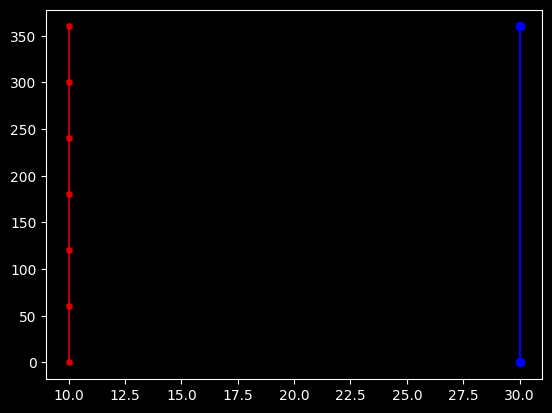

In [40]:
fig1, ax1 = plt.subplots()

ax1.plot(*linea_2.coords.xy, '-o', color='blue')

lunghezza_linea = linea_1.length
n_segmenti = int(np.round(lunghezza_linea / 60))

distanze_ottimizzate = np.linspace(0, lunghezza_linea, n_segmenti + 1)
punti_taglio = [linea_1.interpolate(d) for d in distanze_ottimizzate]
x_coord = [p.x for p in punti_taglio]
y_coord = [p.y for p in punti_taglio]

ax1.plot(x_coord, y_coord, 'o-', color='red', markersize=4, linewidth=1.5, alpha=0.7)

plt.show()

In [41]:
print(punti_taglio)

[<POINT (10 0)>, <POINT (10 60)>, <POINT (10 120)>, <POINT (10 180)>, <POINT (10 240)>, <POINT (10 300)>, <POINT (10 360)>]


In [42]:
coordinate_linea_12d = np.column_stack((x_coord, y_coord))
coordinate_linea_1 = np.column_stack((x_coord, y_coord, np.zeros_like(x_coord)))
print(coordinate_linea_1)

[[ 10.   0.   0.]
 [ 10.  60.   0.]
 [ 10. 120.   0.]
 [ 10. 180.   0.]
 [ 10. 240.   0.]
 [ 10. 300.   0.]
 [ 10. 360.   0.]]


In [43]:
prev_p = np.roll(coordinate_linea_12d, 1, axis=0)  # Punto precedente
next_p = np.roll(coordinate_linea_12d, -1, axis=0)  # Punto successivo
tangent = next_p - prev_p

gamma = -np.radians(5)

tangent_norm = np.linalg.norm(tangent, axis=1, keepdims=True)

tangent_norm[tangent_norm == 0] = 1e-10
new_tangent = (-tangent / tangent_norm) * np.sin(gamma)
tail_2d = coordinate_linea_12d - new_tangent
z_coord = np.cos(gamma)
tail_z = np.full((coordinate_linea_12d.shape[0], 1), z_coord)
coordinate_1 = np.hstack((coordinate_linea_1, tail_2d, tail_z))
print(coordinate_1)

[[1.00000000e+01 0.00000000e+00 0.00000000e+00 1.00000000e+01
  8.71557427e-02 9.96194698e-01]
 [1.00000000e+01 6.00000000e+01 0.00000000e+00 1.00000000e+01
  5.99128443e+01 9.96194698e-01]
 [1.00000000e+01 1.20000000e+02 0.00000000e+00 1.00000000e+01
  1.19912844e+02 9.96194698e-01]
 [1.00000000e+01 1.80000000e+02 0.00000000e+00 1.00000000e+01
  1.79912844e+02 9.96194698e-01]
 [1.00000000e+01 2.40000000e+02 0.00000000e+00 1.00000000e+01
  2.39912844e+02 9.96194698e-01]
 [1.00000000e+01 3.00000000e+02 0.00000000e+00 1.00000000e+01
  2.99912844e+02 9.96194698e-01]
 [1.00000000e+01 3.60000000e+02 0.00000000e+00 1.00000000e+01
  3.60087156e+02 9.96194698e-01]]


In [44]:
coordinate_linea_22d = np.asarray(punti_di_controllo_2, dtype=np.float64)
print(coordinate_linea_22d)

[[ 30.   0.]
 [ 30. 360.]]


In [45]:
prev_p = np.roll(coordinate_linea_22d, 1, axis=0)  # Punto precedente
next_p = np.roll(coordinate_linea_22d, -1, axis=0)  # Punto successivo
tangent = next_p - prev_p

gamma = -np.radians(5)

tangent_norm = np.linalg.norm(tangent, axis=1, keepdims=True)

tangent_norm[tangent_norm == 0] = 1e-10
new_tangent = (-tangent / tangent_norm) * np.sin(gamma)
tail_2d = coordinate_linea_22d - new_tangent
z_coord = np.cos(gamma)
tail_z = np.full((coordinate_linea_22d.shape[0], 1), z_coord)
coordinate_linea_2 = np.column_stack((coordinate_linea_22d, np.zeros_like(tail_z)))
coordinate_2 = np.hstack((coordinate_linea_2, tail_2d, tail_z))
print(coordinate_2)

[[ 30.          0.          0.         30.          0.          0.9961947]
 [ 30.        360.          0.         30.        360.          0.9961947]]


In [46]:
coordinate = np.vstack((coordinate_1, coordinate_2))
coordinate = np.round(coordinate, 3)
print(coordinate)

[[1.00000e+01 0.00000e+00 0.00000e+00 1.00000e+01 8.70000e-02 9.96000e-01]
 [1.00000e+01 6.00000e+01 0.00000e+00 1.00000e+01 5.99130e+01 9.96000e-01]
 [1.00000e+01 1.20000e+02 0.00000e+00 1.00000e+01 1.19913e+02 9.96000e-01]
 [1.00000e+01 1.80000e+02 0.00000e+00 1.00000e+01 1.79913e+02 9.96000e-01]
 [1.00000e+01 2.40000e+02 0.00000e+00 1.00000e+01 2.39913e+02 9.96000e-01]
 [1.00000e+01 3.00000e+02 0.00000e+00 1.00000e+01 2.99913e+02 9.96000e-01]
 [1.00000e+01 3.60000e+02 0.00000e+00 1.00000e+01 3.60087e+02 9.96000e-01]
 [3.00000e+01 0.00000e+00 0.00000e+00 3.00000e+01 0.00000e+00 9.96000e-01]
 [3.00000e+01 3.60000e+02 0.00000e+00 3.00000e+01 3.60000e+02 9.96000e-01]]


In [47]:
for coord in coordinate:
    riga = ""
    for x in coord:
        if x is coord[-1]:
            riga = riga + f"{x}\n"
        else:
            riga = riga + f"{x}, "
    print(riga)

10.0, 0.0, 0.0, 10.0, 0.087, 0.996, 
10.0, 60.0, 0.0, 10.0, 59.913, 0.996, 
10.0, 120.0, 0.0, 10.0, 119.913, 0.996, 
10.0, 180.0, 0.0, 10.0, 179.913, 0.996, 
10.0, 240.0, 0.0, 10.0, 239.913, 0.996, 
10.0, 300.0, 0.0, 10.0, 299.913, 0.996, 
10.0, 360.0, 0.0, 10.0, 360.087, 0.996, 
30.0, 0.0, 0.0, 30.0, 0.0, 0.996, 
30.0, 360.0, 0.0, 30.0, 360.0, 0.996, 


In [48]:
offset = np.array([850, 20, 0, 850, 20, 0], dtype=np.float64)
coordinate = coordinate + offset

for coord in coordinate:
    riga = ""
    for x in coord:
        if x is coord[-1]:
            riga = riga + f"{x}\n"
        else:
            riga = riga + f"{x}, "
    print(riga)

860.0, 20.0, 0.0, 860.0, 20.087, 0.996, 
860.0, 80.0, 0.0, 860.0, 79.913, 0.996, 
860.0, 140.0, 0.0, 860.0, 139.913, 0.996, 
860.0, 200.0, 0.0, 860.0, 199.913, 0.996, 
860.0, 260.0, 0.0, 860.0, 259.913, 0.996, 
860.0, 320.0, 0.0, 860.0, 319.913, 0.996, 
860.0, 380.0, 0.0, 860.0, 380.087, 0.996, 
880.0, 20.0, 0.0, 880.0, 20.0, 0.996, 
880.0, 380.0, 0.0, 880.0, 380.0, 0.996, 
